# 🏗️ TUTORIAL PyMLDA

## Objetivo
Este tutorial ensina como usar o **PyMLDA** para:
1. **Detecção de Danos** (Classificação) - Identificar se há dano e seu tipo
2. **Quantificação de Danos** (Regressão) - Estimar a severidade do dano

## Dados Utilizados
- **Features**: DI-1 e DI-2 (Índices de Dano)
- **Target (Classificação)**: Categorias de dano (Healthy, 2,96% Damage, 5,92% Damage, 8,87% Damage)
- **Target (Regressão)**: Mass loss [%] (Perda de massa)

## O que é PyMLDA?
PyMLDA é um pacote Python para Machine Learning aplicado à **Monitoramento de Saúde Estrutural (SHM)**. Ele integra:
- Extração de features
- Modelos de ML (classificação, regressão, clustering)
- Pipeline completo para análise SHM

#1-INSTALAÇÃO DO PyMLDA

In [1]:
!pip install --upgrade --no-cache-dir git+https://github.com/MOSS-vLab/pymlda.git

  Cloning https://github.com/MOSS-vLab/pymlda.git to /tmp/pip-req-build-8byeha2u
  Running command git clone --filter=blob:none --quiet https://github.com/MOSS-vLab/pymlda.git /tmp/pip-req-build-8byeha2u
  Resolved https://github.com/MOSS-vLab/pymlda.git to commit c4fd3c8eac7c0620e12b88d339b1a57b7f359978
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pymlda: filename=pymlda-0.2.0-py3-none-any.whl size=34902 sha256=f246ab190ce1bffd0fd0ac8ab8eccf93eb53001466662366269c77b4d1fc1288
  Stored in directory: /tmp/pip-ephem-wheel-cache-8fx090up/wheels/45/6a/78/bfa6a46c7109a87cb5d3aae66e9c351f5323869db2f2d1ad14
Successfully built pymlda


#2- IMPORTAÇÃO DE BIBLIOTECAS

Importamos as bibliotecas necessárias:
- **PyMLDA**: Para modelos de ML e pipeline SHM
- **sklearn**: Para pré-processamento e métricas
- **pandas, numpy**: Para manipulação de dados
- **matplotlib, seaborn**: Para visualizações

In [2]:
import pymlda

In [109]:
# PyMLDA - Módulos principais
from pymlda import (
    ClassifierFactory,      # Fábrica de classificadores
    RegressionFactory,      # Fábrica de regressores
    ClusteringFactory,      # Fábrica de clusterizadores
    FeatureManager,         # Gerenciador de features
    MLDA                    # Pipeline completo
)
from pymlda.utils import load_excel, split_data
from pymlda.features import extract_features
from pymlda.ml.evaluation.metrics import compute_classification_metrics
from pymlda.utils.plots import plot_density_by_group

# Sklearn - Pré-processamento e métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    r2_score, mean_squared_error
)

# Bibliotecas básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#3- CARREGAMENTO DOS DADOS

Os dados estão em um arquivo Excel com a planilha `DI_FRAC`.
As colunas são:
- **DI-1**: Índice de Dano 1 (Feature 1)
- **DI-2**: Índice de Dano 2 (Feature 2)
- **Mass loss [%]**: Perda de massa (Target para regressão)
- **Multiclass classification**: Categoria de dano (Target para classificação)

In [8]:
df=load_excel('/content/DI_FRAC_Exp-estimation(1).xlsx',sheet_name='DI_FRAC')
print(df.shape)
df.head()

(140, 4)


,Mass loss [%],DI-1,DI-2,Multiclass classification
0,0.0,0.6178,0.7654,Healthy
1,0.0,0.8038,0.7931,Healthy
2,0.0,0.6889,0.6220,Healthy
3,0.0,0.6889,0.7672,Healthy
4,0.0,0.8376,0.9066,Healthy


#4- ANÁLISE EXPLORATÓRIA DOS DADOS

Vamos visualizar a distribuição das classes e a relação entre as features. Checar o balanceamento dos dados

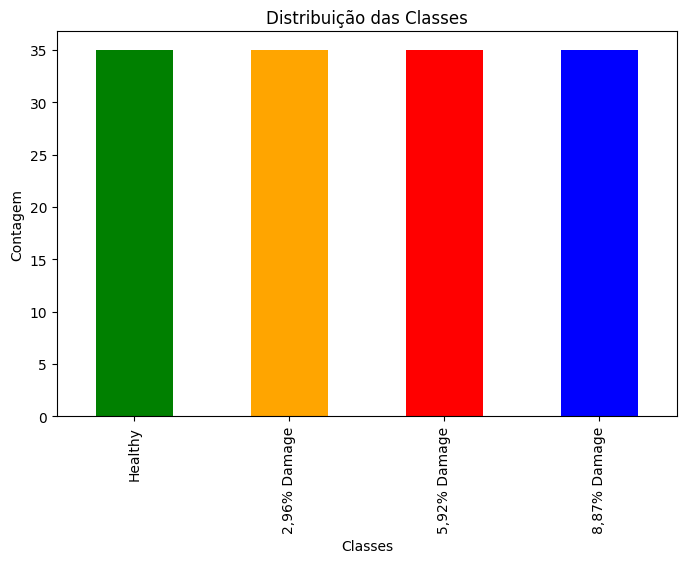

In [11]:
#Distribuição das classes
plt.figure(figsize=(8,5))
df["Multiclass classification"].value_counts().plot(kind="bar", color=['green', 'orange','red', 'blue'])
plt.xlabel("Classes")
plt.ylabel("Contagem")
plt.title("Distribuição das Classes")
plt.show()

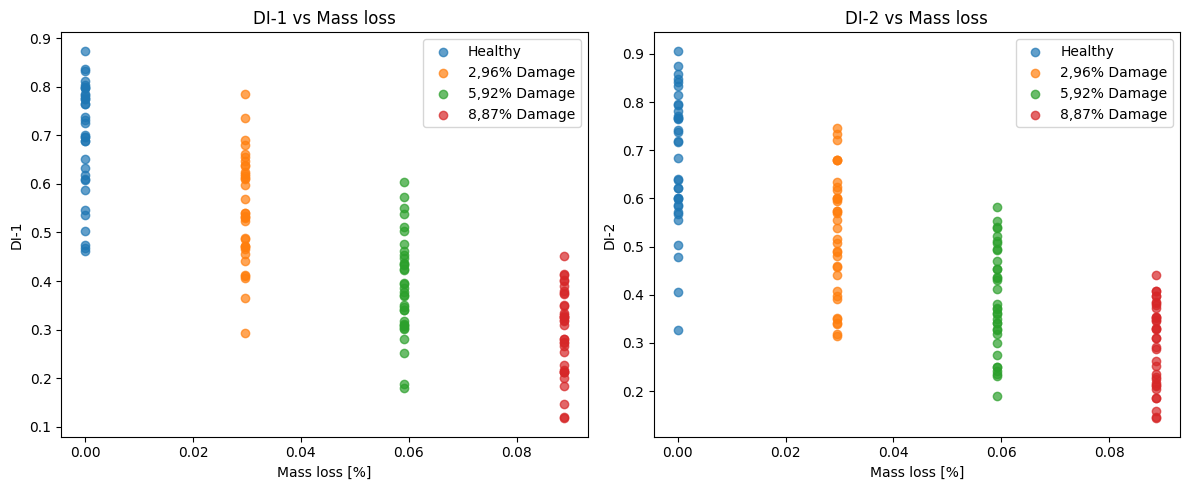

In [23]:
# Relação entre as features e o dano (DI vs Perda de massa)
plt.figure(figsize=(12, 5))

#DI-1
plt.subplot(1, 2, 1)
for classe in df['Multiclass classification'].unique():
    dados = df['Multiclass classification'] == classe
    plt.scatter(df.loc[dados, 'Mass loss [%]'], df.loc[dados, 'DI-1'],
                label=classe, alpha=0.7)
plt.xlabel('Mass loss [%]')
plt.ylabel('DI-1')
plt.title('DI-1 vs Mass loss')
plt.legend()

#DI-2
plt.subplot(1, 2, 2)
for classe in df['Multiclass classification'].unique():
    dados = df['Multiclass classification'] == classe
    plt.scatter(df.loc[dados, 'Mass loss [%]'], df.loc[dados, 'DI-2'],
                label=classe, alpha=0.7)
plt.xlabel('Mass loss [%]')
plt.ylabel('DI-2')
plt.title('DI-2 vs Mass loss')
plt.legend()

plt.tight_layout()
plt.show()

# 5- CLUSTERING - ANÁLISE NÃO SUPERVISIONADA

O clustering ajuda a identificar grupos naturais nos dados.
Usamos o **K-Means** com o método do cotovelo para encontrar o número ideal de clusters

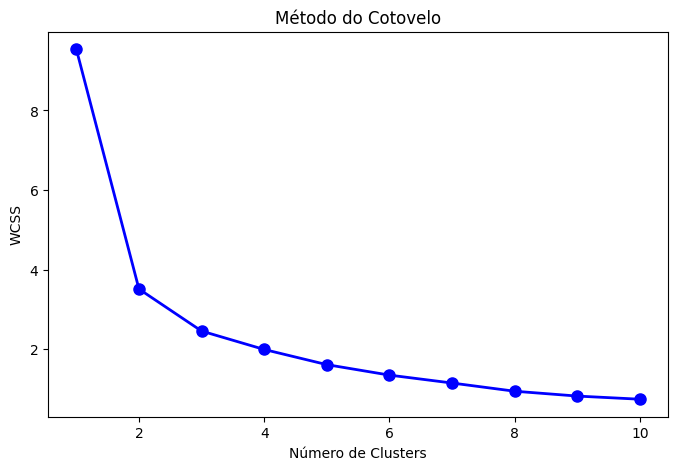

In [25]:
#Dados para clustering
X_cluster=df[['DI-1','DI-2']].values

#Método do cotovelo
wcss=ClusteringFactory.elbow_method(X_cluster, max_k=10, random_state=0)
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss, 'bo-', linewidth=2, markersize=8)
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.show()


In [55]:
#Aplicar k-Means com k=4
k=4
kmeans= ClusteringFactory.get('kmeans', n_clusters=k, random_state=0, n_init=10)
labels=kmeans.fit_predict(X_cluster)
print(f"Clusters identificados: {len(np.unique(labels))}")
print("Distribuição:")
print(pd.Series(labels).value_counts().sort_index())

Clusters identificados: 4
Distribuição:
0    45
1    27
2    25
3    43
Name: count, dtype: int64


In [56]:
# Centróides dos clusters
centroides = kmeans.cluster_centers_

# Distância de cada centróide ao ponto ideal (1,1)
distancias = np.sqrt(
    (centroides[:, 0] - 1)**2 +
    (centroides[:, 1] - 1)**2)

# Ordenar do mais próximo ao mais distante de (1,1)
ordem = np.argsort(distancias)

# Criar o novo mapeamento
mapa = {cluster: novo for novo, cluster in enumerate(ordem)}

# Renomear os clusters
labels_ordenados = np.array([mapa[label] for label in labels])

print("Distribuição:")
print(pd.Series(labels_ordenados).value_counts().sort_index())

Distribuição:
0    25
1    27
2    45
3    43
Name: count, dtype: int64


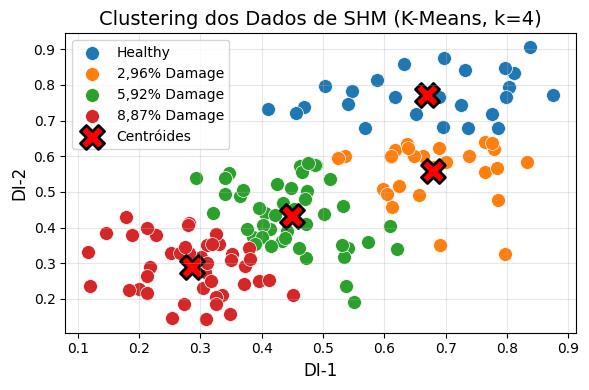

In [58]:
# Visualizar clusters
plt.figure(figsize=(6, 4))
cluster_names = ['Healthy','2,96% Damage', '5,92% Damage', '8,87% Damage' ]

for i in range(k):
    mask = labels_ordenados == i
    plt.scatter(X_cluster[mask, 0], X_cluster[mask, 1],
                s=100, edgecolor='white', linewidth=0.5,
                label=cluster_names[i])

# Centróides
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='red', marker='X', edgecolor='black', linewidth=2,
            label='Centróides')

plt.xlabel('DI-1', fontsize=12)
plt.ylabel('DI-2', fontsize=12)
plt.title('Clustering dos Dados de SHM (K-Means, k=4)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6-PREPARAÇÃO PARA CLASSIFICAÇÃO

Vamos preparar os dados para a classificação:
1. Adicionar o cluster como feature
2. Codificar as classes
3. Dividir em treino/teste e balancear os dados
4. Normalizar os dados

In [65]:
# Adicionar o cluster como feature
X= np.column_stack([df[['DI-1','DI-2']].values, labels_ordenados])
y=df['Multiclass classification'].values

print(f"Features: {X.shape}")
print(f"Classes: {np.unique(y)}")

Features: (140, 3)
Classes: ['2,96% Damage' '5,92% Damage' '8,87% Damage' 'Healthy']


In [66]:
#Codificar classes(transformar números)
le=LabelEncoder()
y_encoded=le.fit_transform(y)
class_names=le.classes_

print(f"\n Classes codificadas:")
for i, nome in enumerate(class_names):
    print(f"   {i}: {nome}")


✅ Classes codificadas:
   0: 2,96% Damage
   1: 5,92% Damage
   2: 8,87% Damage
   3: Healthy


In [67]:
# Dividir dados e balanceamento (treino 80%, teste 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded) #Stratify: mantem a proporção de cada classe no treinamento e teste

print(f"\nTreino: {len(X_train)} amostras")
print(f"Teste: {len(X_test)} amostras")


Treino: 112 amostras
Teste: 28 amostras


In [74]:
# Normalizar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n Dados normalizados!")


 Dados normalizados!


# 7- CLASSIFICAÇÃO - DETECÇÃO DE DANOS

Usamos o **PyMLDA** para treinar e avaliar múltiplos classificadores:
- **Random Forest**: Ensemble de árvores de decisão
- **SVM**: Máquina de Vetores de Suporte
- **KNN**: K-Vizinhos Mais Próximos

O objetivo é classificar os dados em 4 categorias de dano.

### Métricas de performances

| Métrica                  | Pergunta que responde                                       | Em termos simples            |
| ------------------------ | ----------------------------------------------------------- | ---------------------------- |
| **Acurácia**  | “Quantas previsões o modelo acertou?”                       | Acertos / total de previsões |
| **Precisão** | “Quando o modelo disse que era dano, ele estava certo?”     | Evita **falsos alarmes**     |
| **Recall**   | “De todos os danos existentes, quantos o modelo encontrou?” | Evita **perder danos**       |
| **F1-score**             | “Como está o equilíbrio entre Precision e Recall?”          | Combina Precision + Recall   |

In [80]:
# Criar classificadores usando o PyMLDA
classifiers = {
    'Random Forest': ClassifierFactory.get('rf', n_estimators=100, random_state=42),
    'SVM': ClassifierFactory.get('svm', kernel='rbf', C=10, random_state=42),
    'KNN': ClassifierFactory.get('knn', n_neighbors=5),
}

print("Treinando e avaliando classificadores...\n")

results_clf = {}
best_acc = 0
best_name = ""
best_pred = None

for name, model in classifiers.items():
    # Treinar
    model.fit(X_train_scaled, y_train)

    # Prever
    y_pred = model.predict(X_test_scaled)

    # Métricas
    metrics = compute_classification_metrics(y_test, y_pred)
    results_clf[name] = metrics

    print(f" {name}:")
    print(f"   Acurácia: {metrics['accuracy']:.4f}")
    print(f"   F1-Score: {metrics['f1']:.4f}")
    print(f"   Precision: {metrics['precision']:.4f}")
    print(f"   Recall: {metrics['recall']:.4f}")

    if metrics['accuracy'] > best_acc:
        best_acc = metrics['accuracy']
        best_name = name
        best_pred = y_pred

print(f"\n MELHOR CLASSIFICADOR: {best_name}")
print(f"   Acurácia: {best_acc:.4f}")

Treinando e avaliando classificadores...

 Random Forest:
   Acurácia: 0.6429
   F1-Score: 0.6429
   Precision: 0.6429
   Recall: 0.6429
 SVM:
   Acurácia: 0.6429
   F1-Score: 0.6429
   Precision: 0.6429
   Recall: 0.6429
 KNN:
   Acurácia: 0.4643
   F1-Score: 0.4643
   Precision: 0.4643
   Recall: 0.4643

 MELHOR CLASSIFICADOR: Random Forest
   Acurácia: 0.6429


In [82]:
# Relatório completo
print(f"\n Relatório de Classificação - {best_name}:")
print(classification_report(y_test, best_pred, target_names=class_names))

#Relatório do SVM
svm_pred = classifiers['SVM'].predict(X_test_scaled)
print("\nRelatório de Classificação - SVM:")
print(classification_report(y_test,svm_pred,target_names=class_names))


 Relatório de Classificação - Random Forest:
              precision    recall  f1-score   support

2,96% Damage       0.57      0.57      0.57         7
5,92% Damage       0.43      0.43      0.43         7
8,87% Damage       0.71      0.71      0.71         7
     Healthy       0.86      0.86      0.86         7

    accuracy                           0.64        28
   macro avg       0.64      0.64      0.64        28
weighted avg       0.64      0.64      0.64        28


Relatório de Classificação - SVM:
              precision    recall  f1-score   support

2,96% Damage       0.43      0.43      0.43         7
5,92% Damage       0.40      0.29      0.33         7
8,87% Damage       0.78      1.00      0.88         7
     Healthy       0.86      0.86      0.86         7

    accuracy                           0.64        28
   macro avg       0.62      0.64      0.62        28
weighted avg       0.62      0.64      0.62        28



##MATRIZ DE CONFUSÃO

A matriz de confusão mostra detalhadamente onde o modelo acerta e erra.
- **Diagonal**: Acertos
- **Fora da diagonal**: Erros (confusões entre classes)

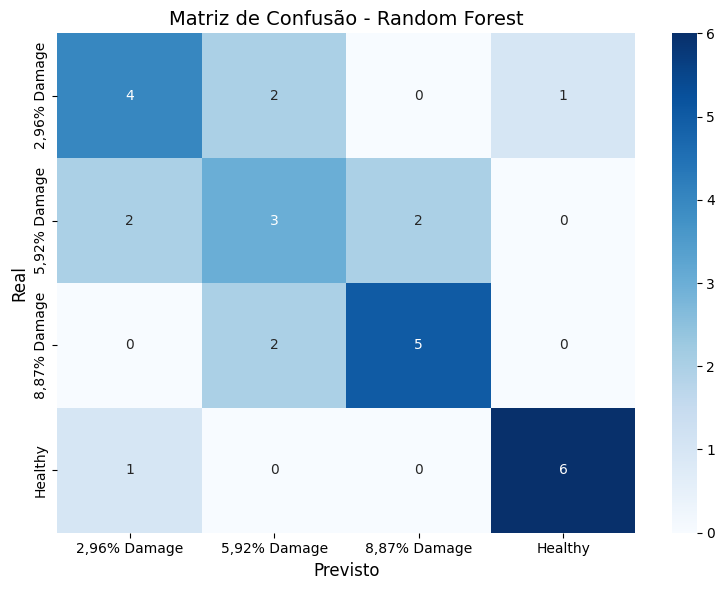


 Interpretação:
   - Acurácia geral: 0.6429
   - Quanto maior a diagonal, melhor a classificação
   - Erros fora da diagonal indicam confusão entre classes


In [83]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsto', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title(f'Matriz de Confusão - {best_name}', fontsize=14)
plt.tight_layout()
plt.show()

print("\n Interpretação:")
print(f"   - Acurácia geral: {best_acc:.4f}")
print(f"   - Quanto maior a diagonal, melhor a classificação")
print(f"   - Erros fora da diagonal indicam confusão entre classes")

# 8- REGRESSÃO - QUANTIFICAÇÃO DE DANOS

A regressão estima a **severidade do dano** (Mass loss [%]) a partir das features.
Usamos **Random Forest**,  **SVR** e **Linear** como modelos principais.

### Processo de Quantificação:
1. **Treinamento**: Aprender a relação features → Mass loss
2. **Validação**: Avaliar a qualidade da estimativa
3. **Predição**: Estimar dano para novos dados
4. **Análise de Densidade**: Avaliar a distribuição das estimativas


### Métricas

| Métrica | O que indica                                  | Melhor resultado |
| ------- | --------------------------------------------- | ---------------- |
| **R²**  | Quanto da variação dos dados o modelo explica | **Próximo de 1** |
| **MSE** | Erro médio ao quadrado                        | **Próximo de 0** |
| **MAE** | Erro absoluto médio                           | **Próximo de 0** |


In [100]:
# Dados para regressão
X_reg = X  # Features já com clusters
y_reg = df['Mass loss [%]'].values

# Dividir dados (80% treino, 20% teste)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

# Normalizar
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

print(f"Treino: {len(X_train_r)} amostras")
print(f"Teste: {len(X_test_r)} amostras")

Treino: 112 amostras
Teste: 28 amostras


In [101]:
# Criar regressor usando o PyMLDA
regressors = {
    'Random Forest': RegressionFactory.get('rf', n_estimators=100, random_state=42),
    'SVR': RegressionFactory.get('svr', kernel='rbf', C=10, epsilon=0.1),
    'Linear': RegressionFactory.get('linear')
}

results_reg = {}
best_r2 = -1
best_reg_name = ""
best_model = None
best_scaler = None
best_y_pred = None  # <-- DEFINIR AQUI

for name, model in regressors.items():
    # Treinar
    model.fit(X_train_r_scaled, y_train_r)

    # Prever no teste
    y_pred = model.predict(X_test_r_scaled)

    # Métricas
    r2 = r2_score(y_test_r, y_pred)
    mse = mean_squared_error(y_test_r, y_pred)
    mae = np.mean(np.abs(y_test_r - y_pred))

    results_reg[name] = {
        'r2': r2,
        'mse': mse,
        'mae': mae,
        'predictions': y_pred,
        'model': model
    }

    print(f" {name}:")
    print(f"   R²: {r2:.4f}")
    print(f"   MSE: {mse:.6f}")
    print(f"   MAE: {mae:.6f}")
    print()

    if r2 > best_r2:
        best_r2 = r2
        best_reg_name = name
        best_model = model
        best_scaler = scaler_r
        best_y_pred = y_pred  # <-- SALVAR A PREDIÇÃO
        best_y_test = y_test_r

print(f"\n MELHOR REGRESSOR: {best_reg_name}")
print(f"   R²: {best_r2:.4f}")

 Random Forest:
   R²: 0.7004
   MSE: 0.000380
   MAE: 0.014694

 SVR:
   R²: -0.0080
   MSE: 0.001280
   MAE: 0.032736

 Linear:
   R²: 0.6978
   MSE: 0.000384
   MAE: 0.015650


 MELHOR REGRESSOR: Random Forest
   R²: 0.7004


## ANÁLISE DE DENSIDADE DAS ESTIMAÇÕES

A análise de densidade mostra a **distribuição das estimativas** para cada classe de dano.
Isso permite avaliar:
1. **Incerteza**: Quão dispersas são as estimativas
2. **Separação**: Quão bem as classes são separadas
3. **Confiabilidade**: Quão confiável é a estimativa para cada classe

### Como interpretar:
- **Pico mais alto**: Valor mais provável para aquela classe
- **Largura do pico**: Incerteza da estimativa (mais largo = mais incerteza)
- **Sobreposição**: Indica confusão entre classes

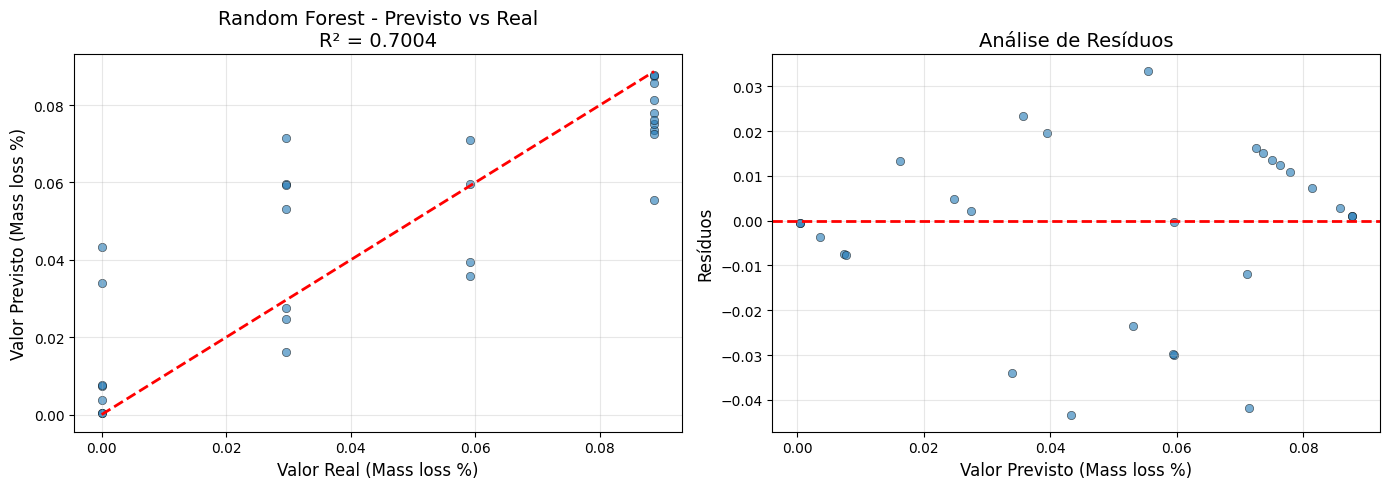


 Interpretação:
   - R² = 0.7004: 70.0% da variância é explicada
   - Resíduos aleatórios indicam bom ajuste
   - Padrão nos resíduos indicaria problema no modelo


In [102]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Previsto vs Real
ax = axes[0]
ax.scatter(best_y_test, best_y_pred, alpha=0.6, edgecolors='k', linewidth=0.5)  # <-- USAR best_y_pred
ax.plot([best_y_test.min(), best_y_test.max()],
        [best_y_test.min(), best_y_test.max()], 'r--', lw=2)
ax.set_xlabel('Valor Real (Mass loss %)', fontsize=12)
ax.set_ylabel('Valor Previsto (Mass loss %)', fontsize=12)
ax.set_title(f'{best_reg_name} - Previsto vs Real\nR² = {best_r2:.4f}', fontsize=14)
ax.grid(True, alpha=0.3)

# Resíduos
ax = axes[1]
residuals = best_y_test - best_y_pred  # <-- USAR best_y_pred
ax.scatter(best_y_pred, residuals, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.axhline(y=0, color='r', linestyle='--', lw=2)
ax.set_xlabel('Valor Previsto (Mass loss %)', fontsize=12)
ax.set_ylabel('Resíduos', fontsize=12)
ax.set_title('Análise de Resíduos', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Interpretação:")
print(f"   - R² = {best_r2:.4f}: {best_r2*100:.1f}% da variância é explicada")
print(f"   - Resíduos aleatórios indicam bom ajuste")
print(f"   - Padrão nos resíduos indicaria problema no modelo")

 Distribuição das estimativas por classe:
              count      mean       std
Classe                                 
2,96% Damage      4  0.013709  0.010610
5,92% Damage      4  0.015427  0.025322
8,87% Damage     10  0.077576  0.008698
Healthy          10  0.049550  0.016394


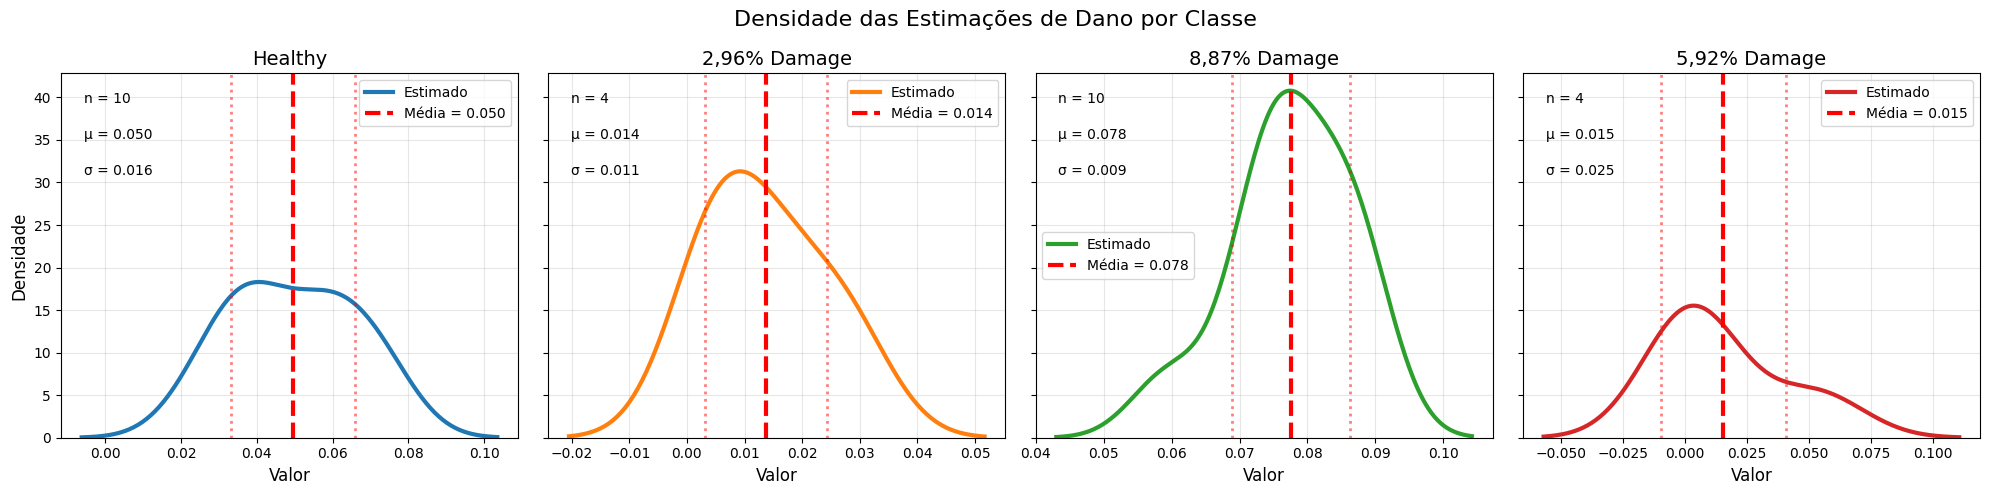


 Gráfico salvo como 'density_damage_estimates.pdf'


In [103]:
# ANÁLISE DE DENSIDADE DAS ESTIMAÇÕES
df_results = pd.DataFrame({
    'Mass_Loss_Real': best_y_test,
    'Mass_Loss_Previsto': best_y_pred,
    'Classe': df.loc[y_test_r.index, 'Multiclass classification'].values if hasattr(y_test_r, 'index') else 'Unknown'
})

# Se não tiver índices, usar os clusters
if 'Classe' not in df_results.columns or df_results['Classe'].iloc[0] == 'Unknown':
    # Usar clusters como referência
    _, y_cluster_indices = train_test_split(labels, test_size=0.2, random_state=42)
    df_results['Classe'] = [cluster_names[i] for i in y_cluster_indices]

print(" Distribuição das estimativas por classe:")
print(df_results.groupby('Classe')['Mass_Loss_Previsto'].agg(['count', 'mean', 'std']))


#Plote da densidade por classe
plot_density_by_group(
    data=df_results,
    group_column='Classe',
    value_column='Mass_Loss_Previsto',
    title='Densidade das Estimações de Dano por Classe',
    save_path='density_plot.pdf')

print("\n Gráfico salvo como 'density_damage_estimates.pdf'")